# Brain stroke prediction using CNN-Transfer Learning

### import necessary packages

In [1]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from keras.utils import Sequence
from keras.applications import InceptionV3
from keras.layers import Dense, Flatten, Dropout
from keras.models import Model
from keras.optimizers import Adam, Nadam, SGD
import matplotlib.pyplot as plt
import pickle

### importing Dataset

In [2]:
datasetpath = './Dataset'

# Global Constants
BS = 64
LR = 1e-2
EPOCHS = 100

In [3]:
print('[INFO Extracting Data and Labels')


def data_labels(datasetpath):
    data = []
    labels = []
    for dirname in os.listdir(datasetpath):
        dirpath = os.path.join(datasetpath, dirname)
        label = dirname.split('.')[-1]
        for filename in os.listdir(dirpath):
            filepath = os.path.join(dirpath, filename)
            print(filepath)
            image = cv2.imread(filepath, 1)
            image = cv2.resize(image, (224, 224))
            data.append(image)
            labels.append(label)
    return np.array(data, dtype='float32') / 255., np.array(labels)


data, labels = data_labels(datasetpath)

[INFO Extracting Data and Labels
./Dataset\Normal\100 (1).jpg
./Dataset\Normal\100 (10).jpg
./Dataset\Normal\100 (11).jpg
./Dataset\Normal\100 (12).jpg
./Dataset\Normal\100 (13).jpg
./Dataset\Normal\100 (14).jpg
./Dataset\Normal\100 (15).jpg
./Dataset\Normal\100 (16).jpg
./Dataset\Normal\100 (17).jpg
./Dataset\Normal\100 (18).jpg
./Dataset\Normal\100 (19).jpg
./Dataset\Normal\100 (2).jpg
./Dataset\Normal\100 (20).jpg
./Dataset\Normal\100 (21).jpg
./Dataset\Normal\100 (22).jpg
./Dataset\Normal\100 (23).jpg
./Dataset\Normal\100 (24).jpg
./Dataset\Normal\100 (25).jpg
./Dataset\Normal\100 (26).jpg
./Dataset\Normal\100 (27).jpg
./Dataset\Normal\100 (28).jpg
./Dataset\Normal\100 (29).jpg
./Dataset\Normal\100 (3).jpg
./Dataset\Normal\100 (30).jpg
./Dataset\Normal\100 (4).jpg
./Dataset\Normal\100 (5).jpg
./Dataset\Normal\100 (6).jpg
./Dataset\Normal\100 (7).jpg
./Dataset\Normal\100 (8).jpg
./Dataset\Normal\100 (9).jpg
./Dataset\Normal\101 (1).jpg
./Dataset\Normal\101 (10).jpg
./Dataset\Normal\

./Dataset\Corona Virus Disease\00030716_000.png
./Dataset\Corona Virus Disease\00030717_000.png
./Dataset\Corona Virus Disease\00030718_000.png
./Dataset\Corona Virus Disease\00030719_000.png
./Dataset\Corona Virus Disease\00030720_001.png
./Dataset\Corona Virus Disease\00030720_002.png
./Dataset\Corona Virus Disease\00030720_003.png
./Dataset\Corona Virus Disease\00030720_004.png
./Dataset\Corona Virus Disease\00030721_000.png
./Dataset\Corona Virus Disease\00030722_000.png
./Dataset\Corona Virus Disease\00030723_000.png
./Dataset\Corona Virus Disease\00030724_000.png
./Dataset\Corona Virus Disease\00030725_000.png
./Dataset\Corona Virus Disease\00030726_000.png
./Dataset\Corona Virus Disease\00030727_000.png
./Dataset\Corona Virus Disease\00030728_000.png
./Dataset\Corona Virus Disease\00030729_000.png
./Dataset\Corona Virus Disease\00030730_000.png
./Dataset\Corona Virus Disease\00030731_000.png
./Dataset\Corona Virus Disease\00030732_000.png
./Dataset\Corona Virus Disease\00030733_

./Dataset\Corona Virus Disease\2C10A413-AABE-4807-8CCE-6A2025594067.jpeg
./Dataset\Corona Virus Disease\4-x-day8.jpg
./Dataset\Corona Virus Disease\44C8E3D6-20DA-42E9-B33B-96FA6D6DE12F.jpeg
./Dataset\Corona Virus Disease\7E335538-2F86-424E-A0AB-6397783A38D0.jpeg
./Dataset\Corona Virus Disease\AR-2.jpg
./Dataset\Corona Virus Disease\ards-secondary-to-tiger-snake-bite.png
./Dataset\Corona Virus Disease\ARDSSevere.png
./Dataset\Corona Virus Disease\aspiration-pneumonia-5-day0.jpg
./Dataset\Corona Virus Disease\aspiration-pneumonia-5-day10.jpg
./Dataset\Corona Virus Disease\aspiration-pneumonia-5-day27.jpg
./Dataset\Corona Virus Disease\aspiration-pneumonia-5-day3.jpg
./Dataset\Corona Virus Disease\auntminnie-a-2020_01_28_23_51_6665_2020_01_28_Vietnam_coronavirus.jpeg
./Dataset\Corona Virus Disease\auntminnie-b-2020_01_28_23_51_6665_2020_01_28_Vietnam_coronavirus.jpeg
./Dataset\Corona Virus Disease\auntminnie-d-2020_01_28_23_51_6665_2020_01_28_Vietnam_coronavirus.jpeg
./Dataset\Corona Viru

./Dataset\Corona Virus Disease\COVID19(201).jpg
./Dataset\Corona Virus Disease\COVID19(202).jpg
./Dataset\Corona Virus Disease\COVID19(203).jpg
./Dataset\Corona Virus Disease\COVID19(204).jpg
./Dataset\Corona Virus Disease\COVID19(205).jpg
./Dataset\Corona Virus Disease\COVID19(206).jpg
./Dataset\Corona Virus Disease\COVID19(207).jpg
./Dataset\Corona Virus Disease\COVID19(208).jpg
./Dataset\Corona Virus Disease\COVID19(21).jpg
./Dataset\Corona Virus Disease\COVID19(211).jpg
./Dataset\Corona Virus Disease\COVID19(212).jpg
./Dataset\Corona Virus Disease\COVID19(213).jpg
./Dataset\Corona Virus Disease\COVID19(214).jpg
./Dataset\Corona Virus Disease\COVID19(215).jpg
./Dataset\Corona Virus Disease\COVID19(216).jpg
./Dataset\Corona Virus Disease\COVID19(217).jpg
./Dataset\Corona Virus Disease\COVID19(218).jpg
./Dataset\Corona Virus Disease\COVID19(219).jpg
./Dataset\Corona Virus Disease\COVID19(22).jpg
./Dataset\Corona Virus Disease\COVID19(220).jpg
./Dataset\Corona Virus Disease\COVID19(221

./Dataset\Corona Virus Disease\COVID19(395).jpg
./Dataset\Corona Virus Disease\COVID19(396).jpg
./Dataset\Corona Virus Disease\COVID19(397).jpg
./Dataset\Corona Virus Disease\COVID19(398).jpg
./Dataset\Corona Virus Disease\COVID19(399).jpg
./Dataset\Corona Virus Disease\COVID19(4).jpg
./Dataset\Corona Virus Disease\COVID19(40).jpg
./Dataset\Corona Virus Disease\COVID19(400).jpg
./Dataset\Corona Virus Disease\COVID19(401).jpg
./Dataset\Corona Virus Disease\COVID19(402).jpg
./Dataset\Corona Virus Disease\COVID19(403).jpg
./Dataset\Corona Virus Disease\COVID19(404).jpg
./Dataset\Corona Virus Disease\COVID19(405).jpg
./Dataset\Corona Virus Disease\COVID19(406).jpg
./Dataset\Corona Virus Disease\COVID19(407).jpg
./Dataset\Corona Virus Disease\COVID19(408).jpg
./Dataset\Corona Virus Disease\COVID19(409).jpg
./Dataset\Corona Virus Disease\COVID19(41).jpg
./Dataset\Corona Virus Disease\COVID19(410).jpg
./Dataset\Corona Virus Disease\COVID19(411).jpg
./Dataset\Corona Virus Disease\COVID19(412).

...

./Dataset\Viral Pneumonia\VIRUS-4176449-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-4177975-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-4178213-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-4198099-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-4217562-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-4218548-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-4233560-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-4241544-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-4241544-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-4241544-0005.jpeg
./Dataset\Viral Pneumonia\VIRUS-4245588-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-4271267-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-428676-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-4293827-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-4313165-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-4320648-0005.jpeg
./Dataset\Viral Pneumonia\VIRUS-4320648-0006.jpeg
./Dataset\Viral Pneumonia\VIRUS-4329463-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-4333878-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-4338635-0004.jpeg
.

./Dataset\Viral Pneumonia\VIRUS-5257922-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-5268802-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-5268966-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-5272604-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-5284146-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-5285130-0006.jpeg
./Dataset\Viral Pneumonia\VIRUS-5289209-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-5294818-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-5315109-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-5328496-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-5331068-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-5334028-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-5346693-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-5364032-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-5366209-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-5366209-0005.jpeg
./Dataset\Viral Pneumonia\VIRUS-5372503-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-537555-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-537555-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-537555-0004.jpeg
./D

./Dataset\Viral Pneumonia\VIRUS-6350019-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-6363370-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-6376704-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-6376704-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-6382033-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-6386500-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-6386500-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-6386500-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-6386500-0005.jpeg
./Dataset\Viral Pneumonia\VIRUS-6386500-0006.jpeg
./Dataset\Viral Pneumonia\VIRUS-6394993-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-6398913-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-6418092-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-6420106-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-6420973-0008.jpeg
./Dataset\Viral Pneumonia\VIRUS-6423688-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-6443888-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-6450342-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-6458918-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-6461260-0002.jpeg


./Dataset\Viral Pneumonia\VIRUS-7630183-0009.jpeg
./Dataset\Viral Pneumonia\VIRUS-7631316-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-7654964-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-7682235-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-7700975-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-7700975-0005.jpeg
./Dataset\Viral Pneumonia\VIRUS-7704214-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-7704214-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-7710112-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-7710693-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-772356-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-772356-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-7736073-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-7746316-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-7760029-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-7776636-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-7777605-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-778527-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-7792467-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-7794093-0005.jpeg
./D

./Dataset\Viral Pneumonia\VIRUS-8806791-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-8814390-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-8833130-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-8841513-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-8841513-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-8845554-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-8849094-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-886684-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-8871315-0003.jpeg
./Dataset\Viral Pneumonia\VIRUS-8888277-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-8917885-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-8939025-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-8939376-0001.jpeg
./Dataset\Viral Pneumonia\VIRUS-8941083-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-894333-0004.jpeg
./Dataset\Viral Pneumonia\VIRUS-8967096-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-8982418-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-8995112-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-8995871-0002.jpeg
./Dataset\Viral Pneumonia\VIRUS-8995871-0003.jpeg
./

### Label Binarization

In [4]:
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

### Split dataset

In [5]:
xTrain, xTest, yTrain, yTest = train_test_split(data, labels, test_size=0.25, stratify=labels, random_state=42)
xTrain.shape, yTrain.shape

((1875, 224, 224, 3), (1875, 1))

### Data Augmentation

In [6]:
aug=ImageDataGenerator(rotation_range=20,
                       shear_range=0.15,
                       width_shift_range=0.2,
                       height_shift_range=0.2,
                       zoom_range=0.15,
                       horizontal_flip=True,
                       fill_mode='nearest')

# testaug = ImageDataGenerator(rescale = 1/255.)


TrainData=aug.flow(xTrain,yTrain, batch_size=BS)
TestData= aug.flow(xTest,yTest, batch_size=BS)

### # Define the Network

In [7]:
inc = InceptionV3(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
for layer in inc.layers:
    layer.trainable = False

x = inc.output
x = Flatten()(x)
x = Dense(32, activation='relu')(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inc.input, outputs=output)

# Compiling the Network
model.compile(optimizer=SGD(learning_rate=LR), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 111, 111, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 111, 111, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                             

### Training Data

In [8]:
print('[INFO] Training Started')
H = model.fit(
        TrainData,
        steps_per_epoch=TrainData.n//BS,
        epochs = EPOCHS,
        validation_data=TestData,
        validation_steps=TestData.n//BS,
         )

[INFO] Training Started
Epoch 1/100
29/29 [==============================] - 28s 723ms/step - loss: 0.6934 - accuracy: 0.6051 - val_loss: 0.6590 - val_accuracy: 0.6198
Epoch 2/100
29/29 [==============================] - 19s 667ms/step - loss: 0.6591 - accuracy: 0.6190 - val_loss: 0.6453 - val_accuracy: 0.6389
Epoch 3/100
29/29 [==============================] - 19s 643ms/step - loss: 0.6431 - accuracy: 0.6383 - val_loss: 0.6397 - val_accuracy: 0.6233
Epoch 4/100
29/29 [==============================] - 18s 636ms/step - loss: 0.6393 - accuracy: 0.6427 - val_loss: 0.6369 - val_accuracy: 0.6458
Epoch 5/100
29/29 [==============================] - 19s 673ms/step - loss: 0.6283 - accuracy: 0.6444 - val_loss: 0.6656 - val_accuracy: 0.6094
Epoch 6/100
29/29 [==============================] - 20s 695ms/step - loss: 0.6316 - accuracy: 0.6461 - val_loss: 0.6374 - val_accuracy: 0.6285
Epoch 7/100
29/29 [==============================] - 20s 682ms/step - loss: 0.6108 - accuracy: 0.6670 - val_loss

### Plot

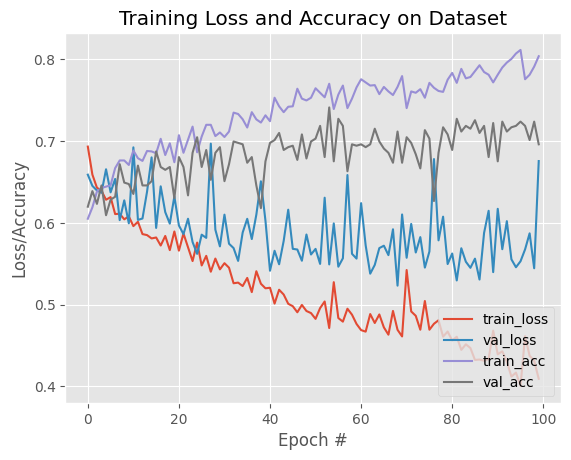

In [9]:
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower right")
plt.savefig('./graphs/graph-incept-100.png')

### Saving Model to disk

In [10]:
print("[INFO] serializing network...")
model.save('model.h5', save_format="h5")
# serialize the label binarizer to disk
f = open('labels-incept-100.h5', "wb")
f.write(pickle.dumps(lb))
f.close()

[INFO] serializing network...


In [12]:
from tensorflow.keras.models import load_model
# load the trained model from disk
print("[INFO] loading model")
model = load_model('model-incept-100.h5')

[INFO] loading model


### Evaluate Model

In [13]:
ypred = model.predict(xTest)
ypred = lb.inverse_transform(ypred)

20/20 [==============================] - 4s 109ms/step


In [14]:
yTest = lb.inverse_transform(yTest)

#### Confusion Matrix

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

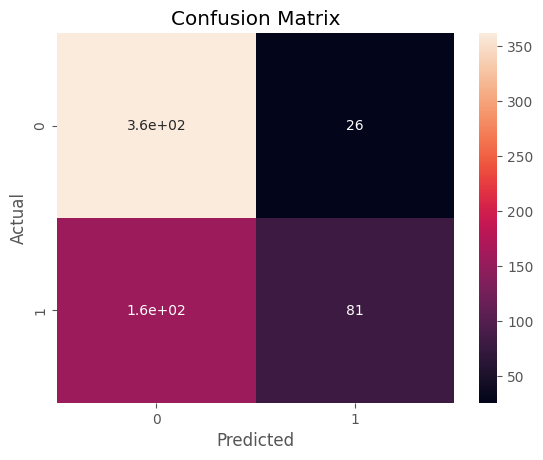

In [16]:
cm = confusion_matrix(yTest, ypred)

import seaborn as sns
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### classification report

In [17]:
class_report = classification_report(yTest, ypred)
print(class_report)

              precision    recall  f1-score   support

      Normal       0.70      0.93      0.80       388
      Stroke       0.76      0.34      0.47       238

    accuracy                           0.71       626
   macro avg       0.73      0.64      0.63       626
weighted avg       0.72      0.71      0.67       626



### Confusion Matrix- Training

In [18]:
ypred = model.predict(xTrain)
ypred = lb.inverse_transform(ypred)

59/59 [==============================] - 4s 61ms/step


In [19]:
yTrain = lb.inverse_transform(yTrain)

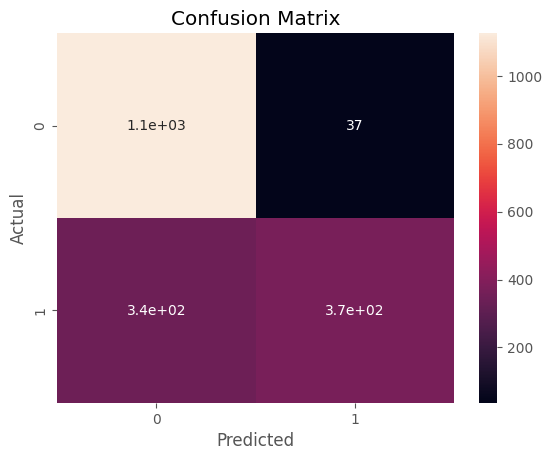

In [20]:
cm = confusion_matrix(yTrain, ypred)

import seaborn as sns
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
class_report = classification_report(yTrain, ypred)
print(class_report)

              precision    recall  f1-score   support

      Normal       0.77      0.97      0.86      1163
      Stroke       0.91      0.52      0.66       712

    accuracy                           0.80      1875
   macro avg       0.84      0.74      0.76      1875
weighted avg       0.82      0.80      0.78      1875

